## Import python lib

In [1]:
%load_ext autoreload
%autoreload 2

from torch import nn,tensor
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
# import model2
import model
import time
import trans
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.profiler import profile, ProfilerActivity
import random
import colorsys
from scipy.constants import h, c, eV
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import r2_score 
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset, DataLoader,random_split
from utility import set_seed,adjust_learning_rate,dataset_division,train,fine_train,myplots,dataload, model_define, datadivision\
    ,fine_train,plot_distribution_and_calculate_probability,parameter_status_table,\
    load_ptmodel,data_loading_wave
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## Data loading

In [3]:
# data loading
Abs, PL_t, PL_b, Image, label,abs_wave,pl_wave,df = data_loading_wave("./1.59eV_data.xlsx",120000,150000,1,0,True)

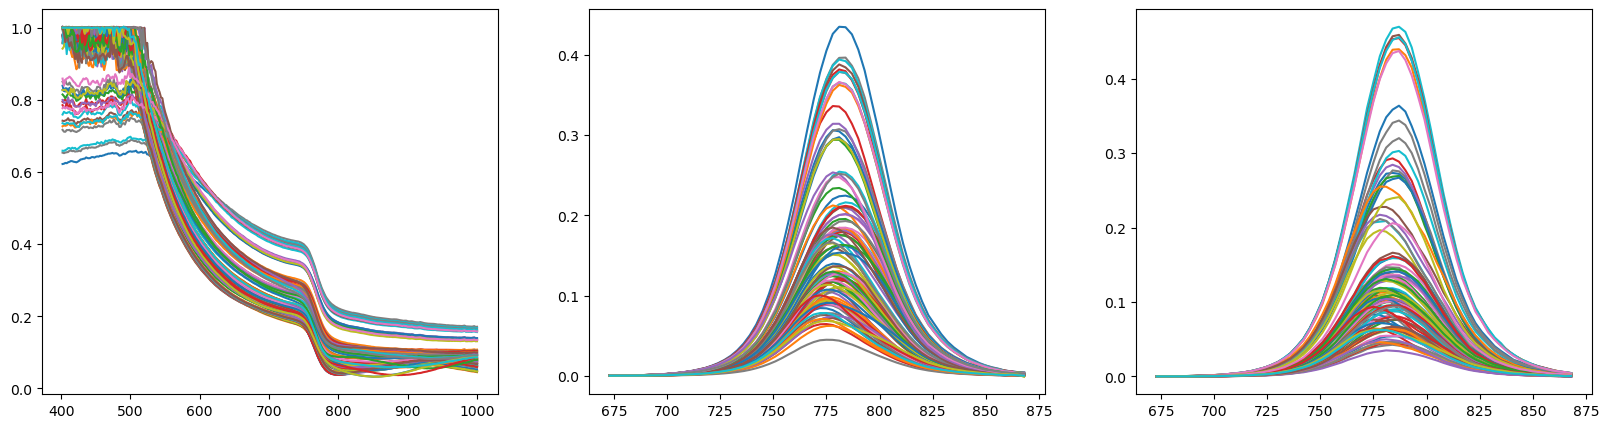

In [4]:
# data visualization
fig,ax = plt.subplots(1,3,figsize=(20,5))
ax[0].plot(abs_wave,Abs[:,0,:].reshape(-1,300).T)
ax[1].plot(pl_wave,PL_t[:,0,:].reshape(-1,66).T)
ax[2].plot(pl_wave,PL_b[:,0,:].reshape(-1,66).T)

# Spectrum feature extraction

## Dataset preparation

In [5]:
batch_size = 128
spectrum = np.concatenate((Abs, PL_t, PL_b),axis=-1)

spectrum_train_dataloader, spectrum_val_dataloader, spectrum_test_dataloader = dataset_division(spectrum,batch_size)
# abs_wavelength_tensor = torch.FloatTensor(abs_wave1).to(device)

In [6]:
spectrum.shape

(100, 2, 432)

## Transformer model definition

In [7]:
params = {
    'batch_size': batch_size,
    'lr':5e-3,
    'min_lr':5e-5,
    'decay_rate': 0.5,
    'epochs':2000,
    'weight_decay':1e-6,
    'warmup_epochs':0,
    'device':device
}
model = model.MAE(
    in_channel=1, embed_dim=36, decoder_dim=18, patch_size=[15,11], stride=[15,11], num_patches=[20,12],   
    mask_ratio=[0.6,0.4], encoder_depth=24,decoder_depth=1,mlp_ratio = 4,qkv_bias = True,
    num_encoder_heads=6, num_decoder_heads=6,device=device
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = params['lr'], weight_decay = params['weight_decay'])

## Train

In [8]:
%%time
train_loss,val_loss,abs_lr = train(model, optimizer, spectrum_train_dataloader, spectrum_val_dataloader, params,norm_spec_loss=False)

Epoch [1/2000], Train Loss: 1.3805913925, Val Loss: 1.2355194092, lr: 0.005000
Epoch [2/2000], Train Loss: 1.1894524097, Val Loss: 0.6346718073, lr: 0.005000
Epoch [3/2000], Train Loss: 0.6396505237, Val Loss: 0.4238917530, lr: 0.005000
Epoch [4/2000], Train Loss: 0.4299241602, Val Loss: 0.3506783545, lr: 0.005000
Epoch [5/2000], Train Loss: 0.3533538282, Val Loss: 0.2909764946, lr: 0.005000
Epoch [6/2000], Train Loss: 0.2939935029, Val Loss: 0.2723260224, lr: 0.005000


KeyboardInterrupt: 

In [9]:
# model saving
torch.save(model.state_dict(), 'Pre-trained_model.pth')

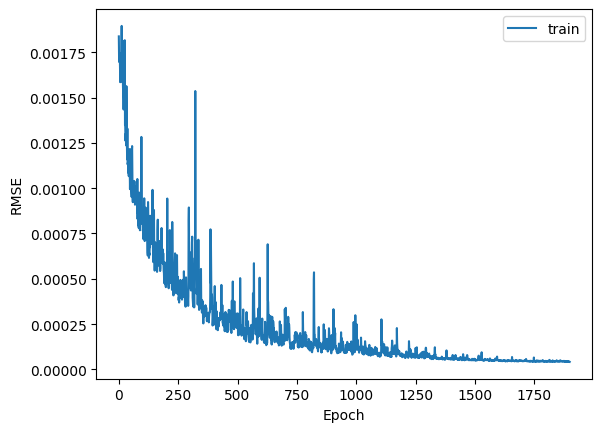

In [14]:
# training loss visualization
plt.plot(train_loss[100:],label = 'train')
# plt.plot(abs_val_loss[50:],label = 'validate')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()

## Test

tensor(5.3135e-05, grad_fn=<DivBackward0>)


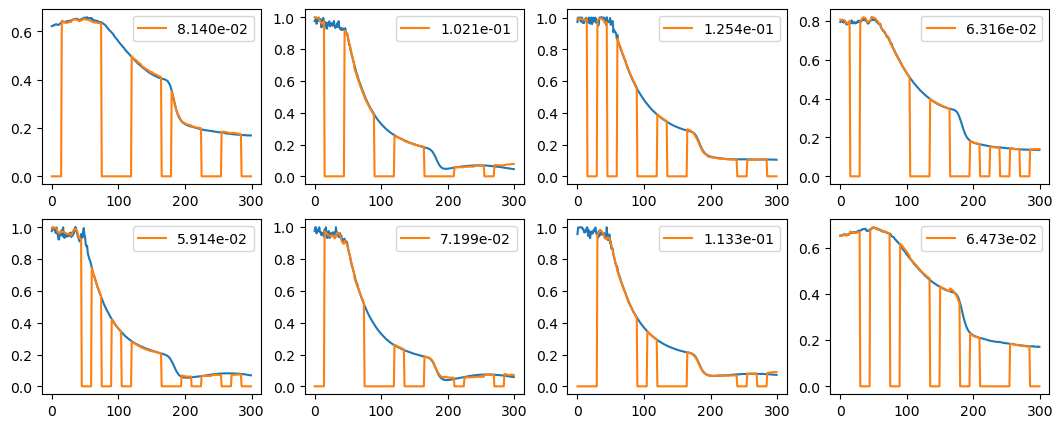

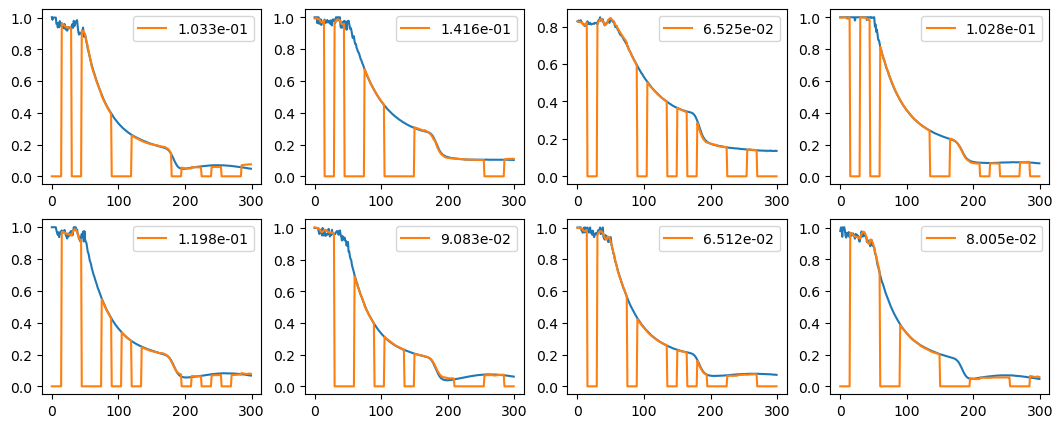

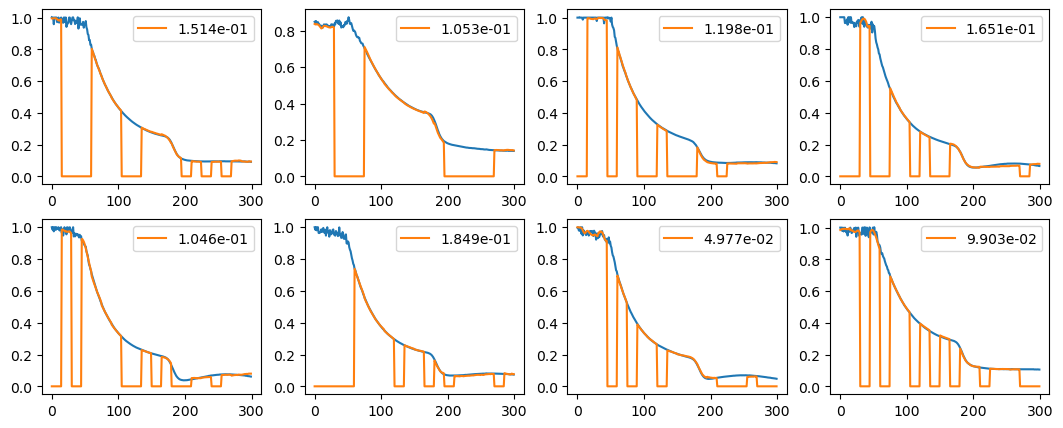

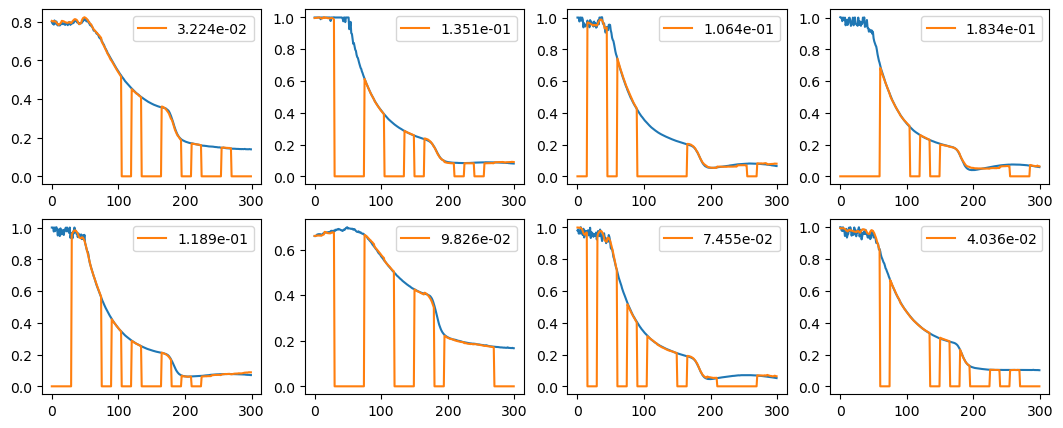

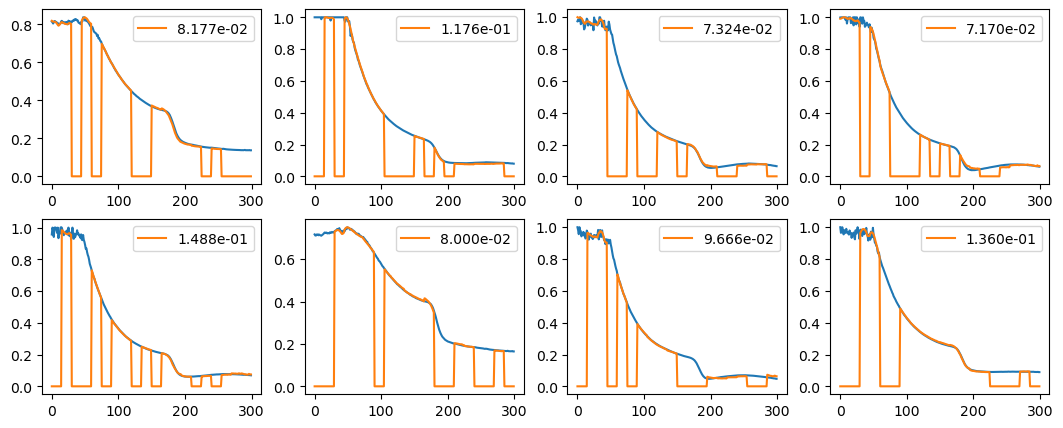

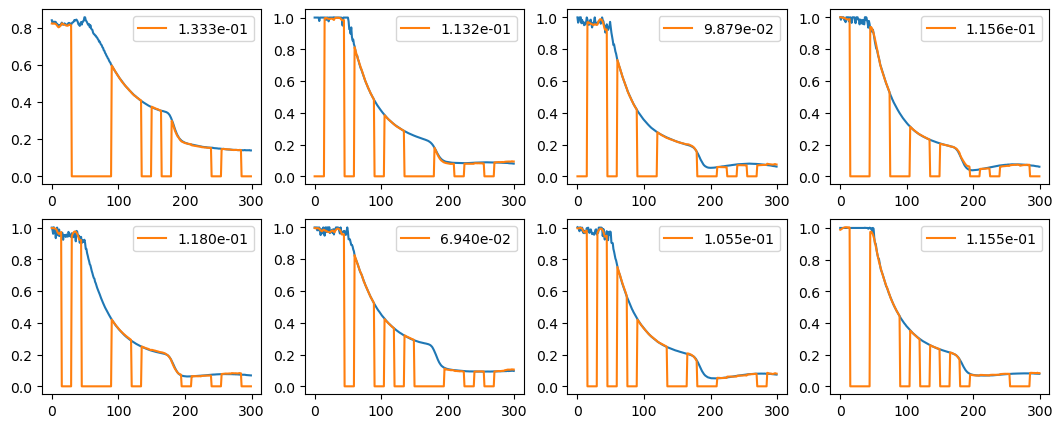

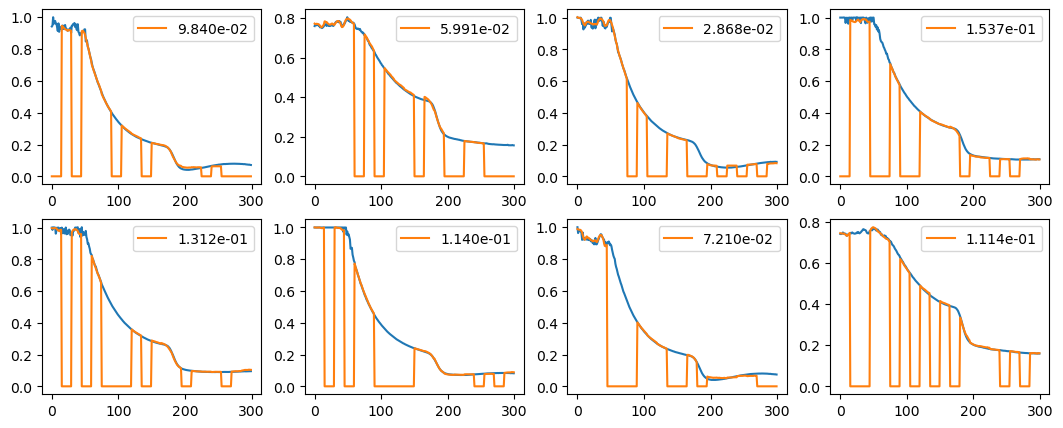

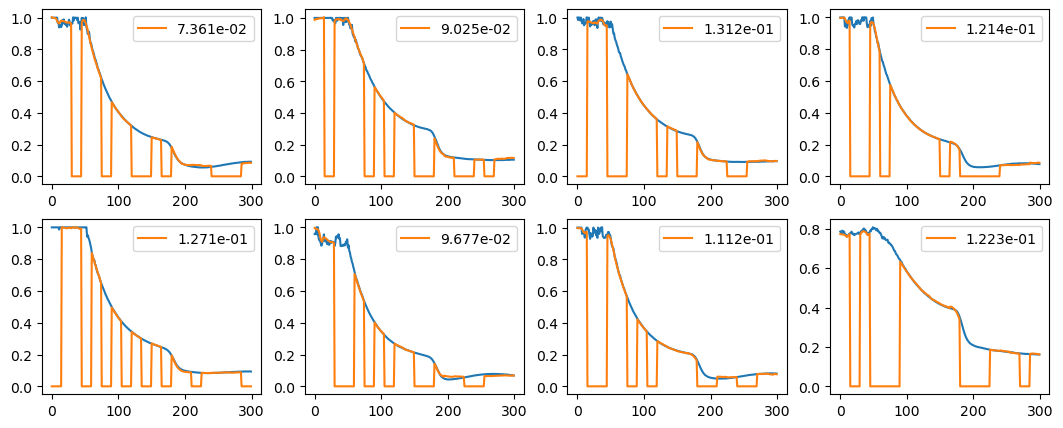

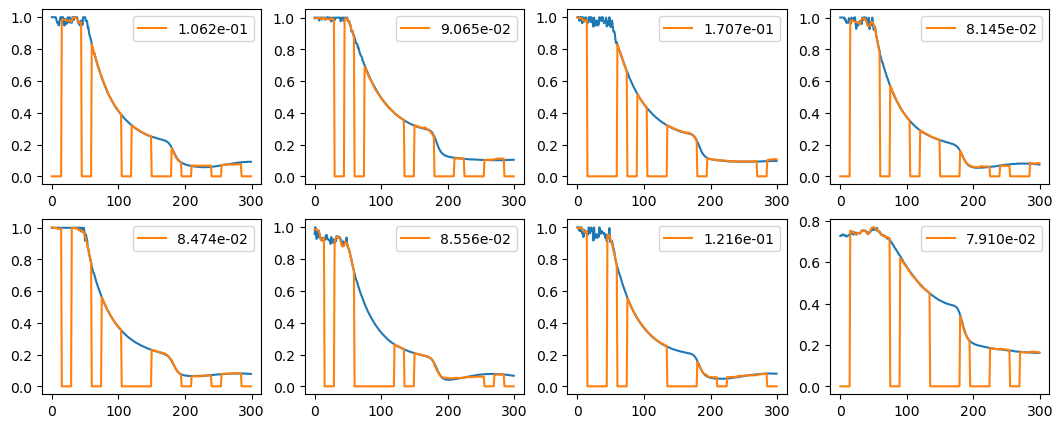

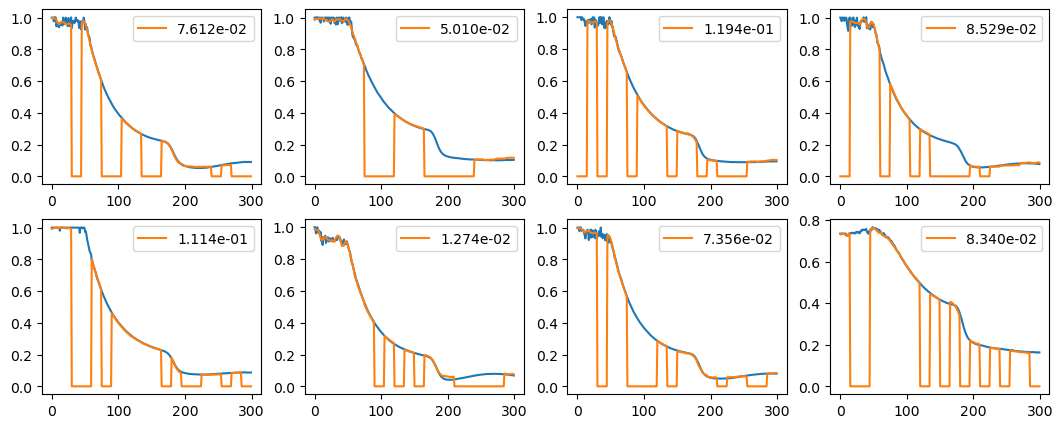

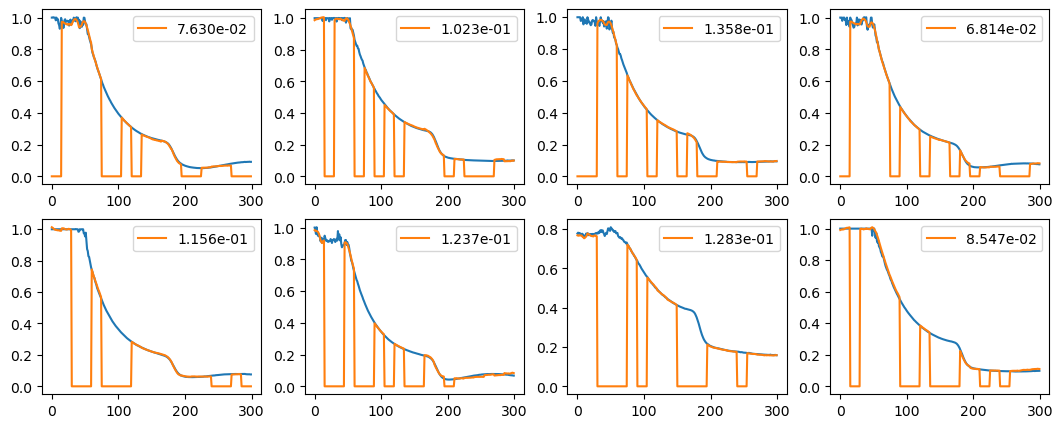

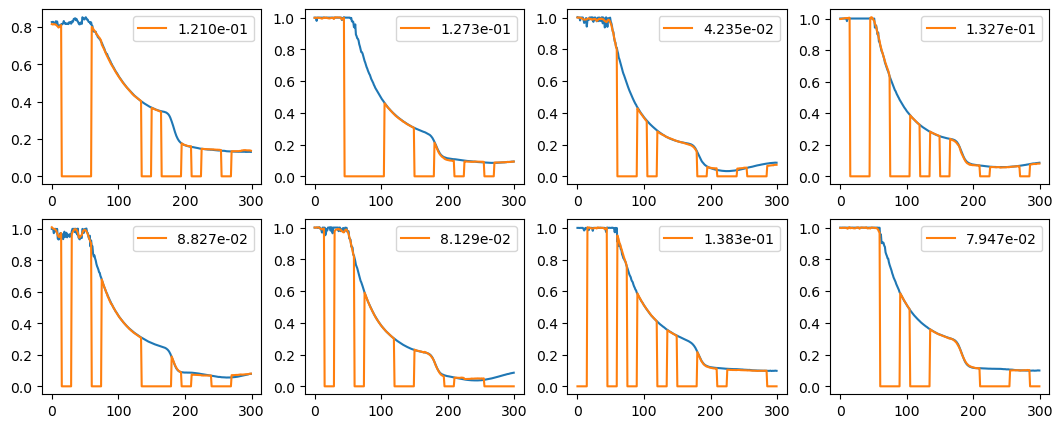

In [11]:
load_model = load_ptmodel('Pre-trained_model.pth','cpu')
load_model.eval()
# test
test_indices = spectrum_train_dataloader.dataset.indices
test_data = torch.FloatTensor(spectrum)

loss, ytrue, ypred, mask = load_model.forward_loss([test_data[:,:,:300],test_data[:,:,300:]],norm_spec_loss=False)
print(loss)
abs_true, pl_true = ytrue[0].detach().numpy().reshape(-1,300), ytrue[1].detach().numpy().reshape(-1,66)
abs_pred, pl_pred = ypred[0].detach().numpy().reshape(-1,300), ypred[1].detach().numpy().reshape(-1,66)
# y_true = ytrue.detach().cpu().numpy().reshape(-1,300)
# y_recons = ypred.detach().cpu().numpy().reshape(-1,300)


n=0
num=12
for i in range(num):
    fig, ax = plt.subplots(2, 4)
    fig.set_size_inches(13, 5)
    ax = ax.reshape(-1)
    for j in range(8):
        ax[j].plot(abs_true[j+8*i,:])
        rmse = np.mean((abs_true[j+8*i,:]-abs_pred[j+8*i,:]) ** 2)
        ax[j].plot(abs_pred[j+8*i,:],label = format(rmse, '.3e'))
        ax[j].legend() 

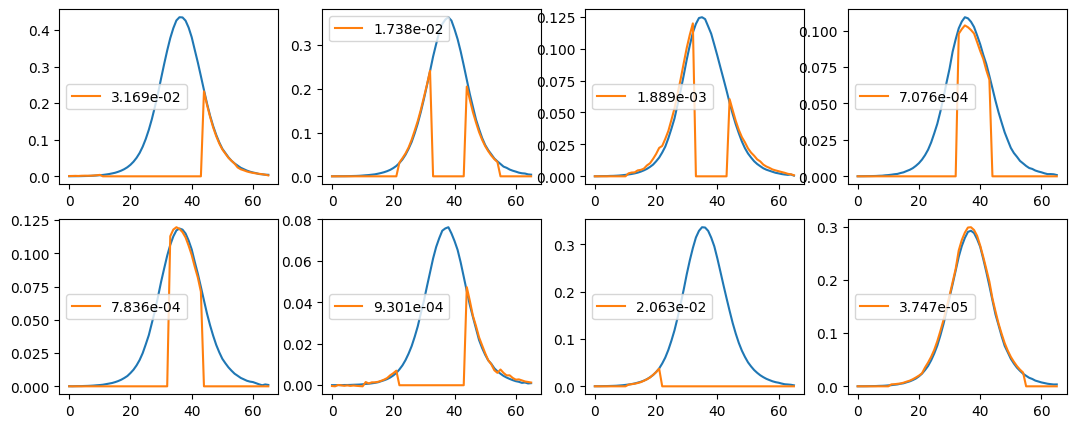

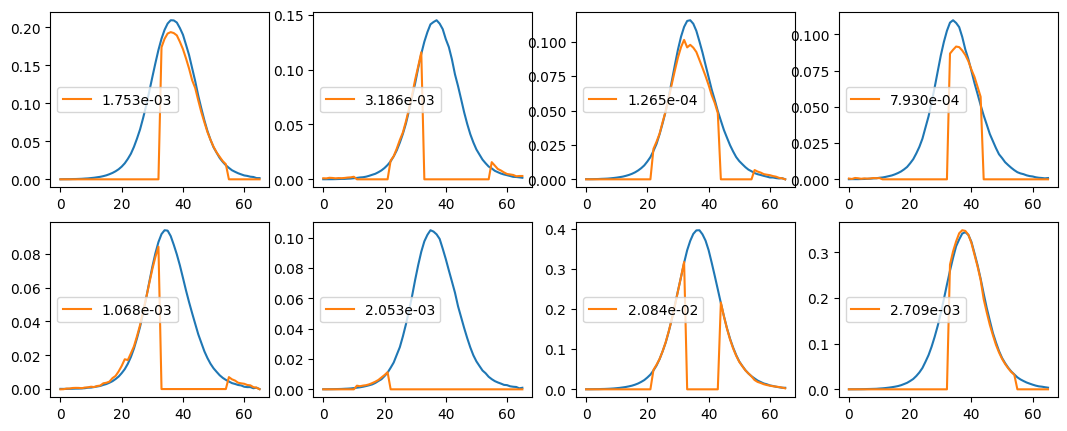

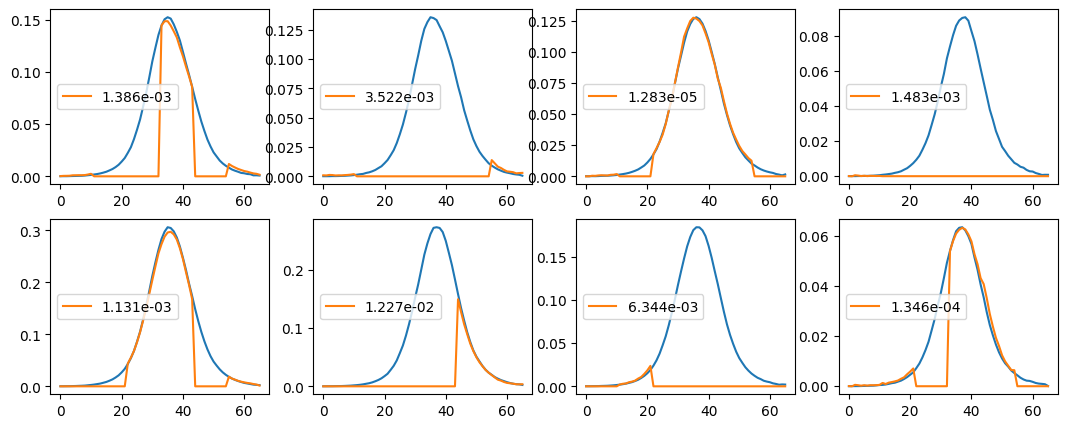

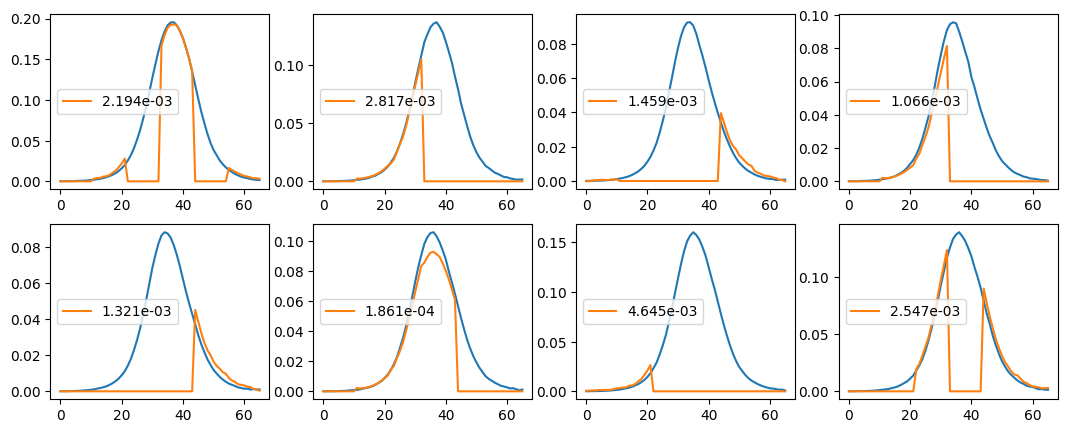

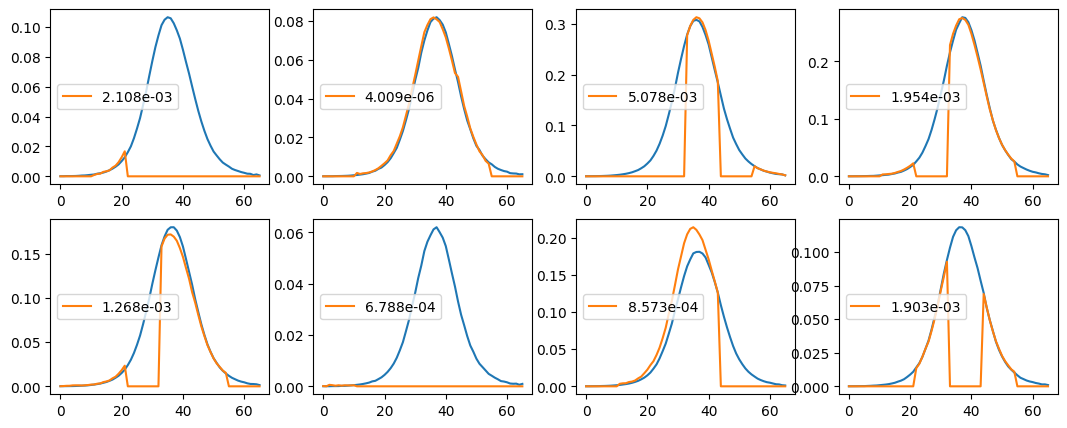

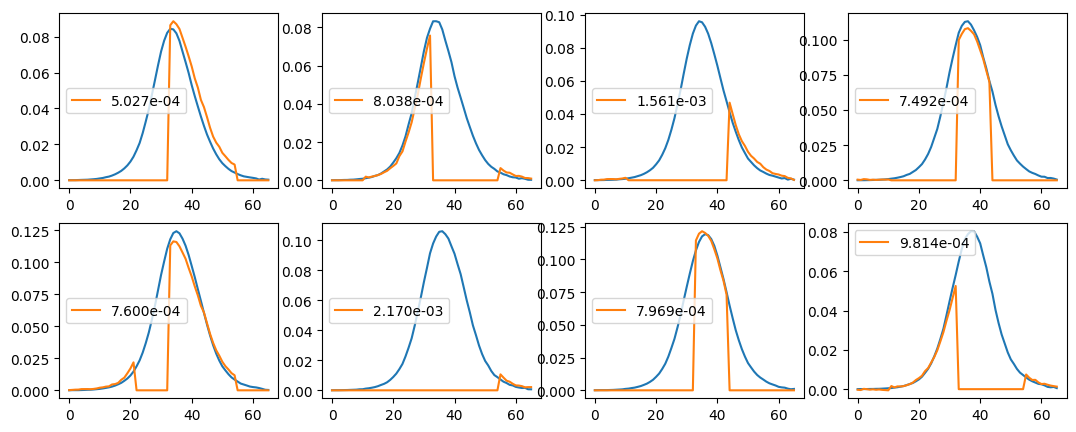

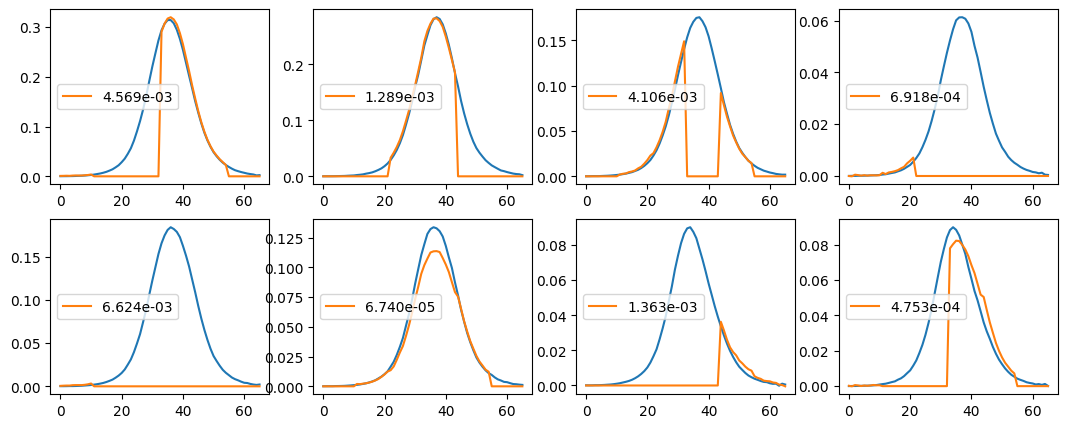

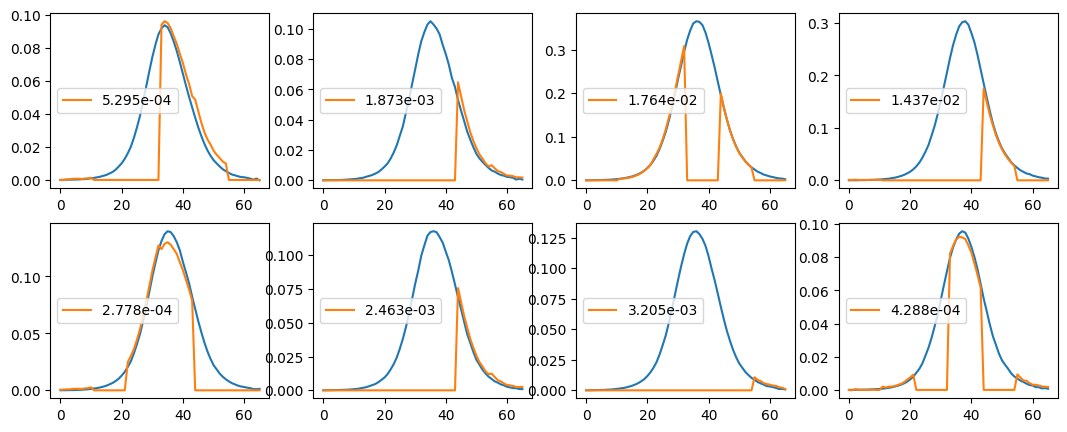

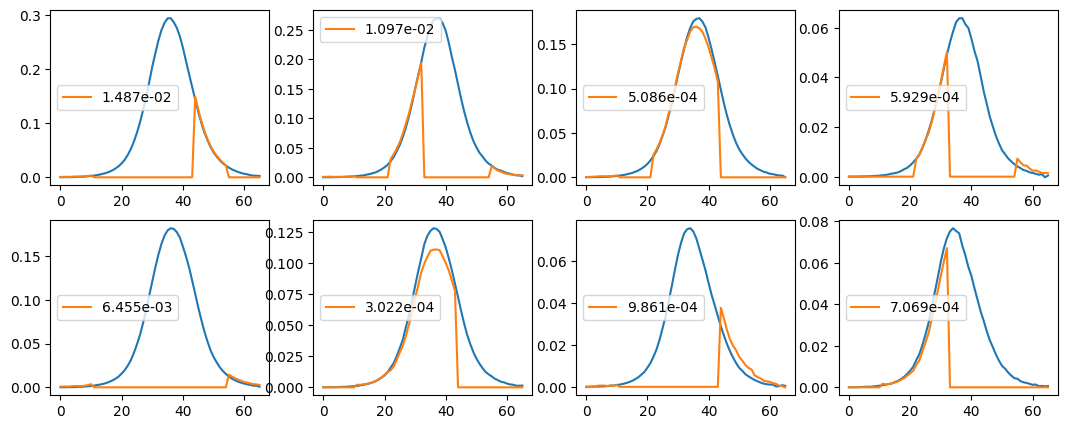

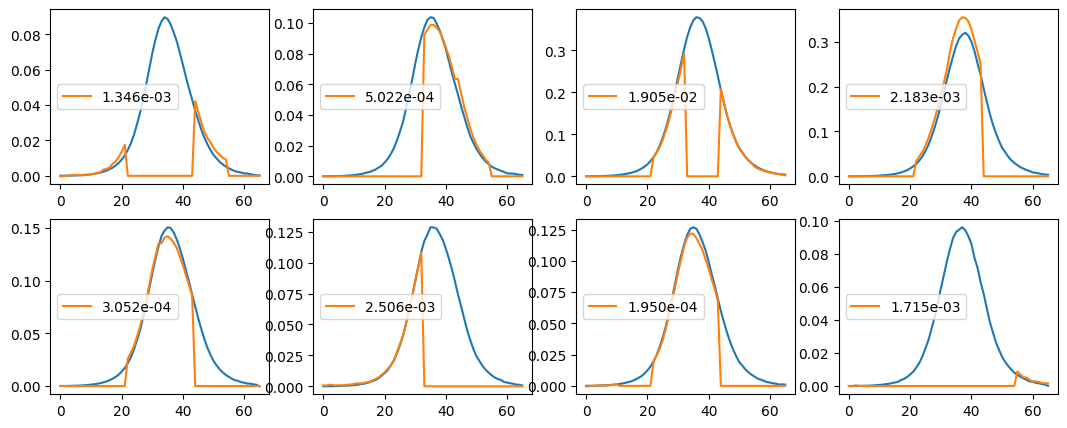

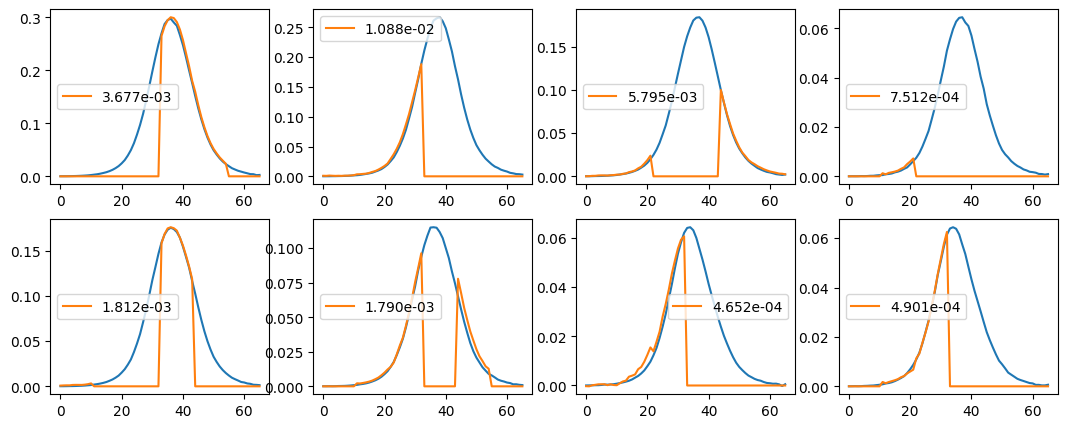

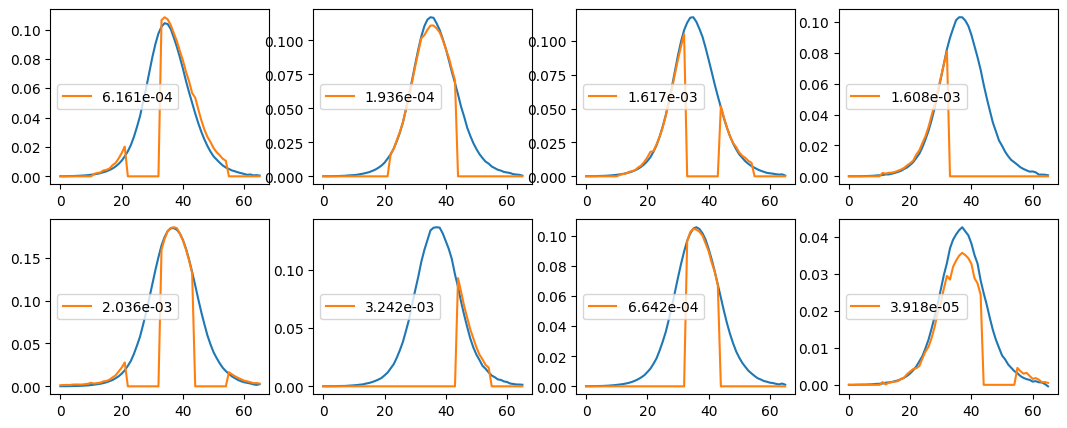

In [13]:
n=0
num=12
for i in range(num):
    fig, ax = plt.subplots(2, 4)
    fig.set_size_inches(13, 5)
    ax = ax.reshape(-1)
    for j in range(8):
        ax[j].plot(pl_true[j+8*i,:])
        rmse = np.mean((pl_true[j+8*i,:]-pl_pred[j+8*i,:]) ** 2)
        ax[j].plot(pl_pred[j+8*i,:],label = format(rmse, '.3e'))
        ax[j].legend() 

# PCE prediction

## Abs & PL feature extraction

In [12]:
#solvent 
abs_train = Abs
pl_train = np.concatenate((PL_t,PL_b),axis=-1)
label_train = label[0]/25
train_index, val_index, test_indices = datadivision(label_train.shape[0],500,1500)

## prediction

Epoch [1/100], Train Loss: 2.2869656980, Val Loss: 1.0894302344, lr: 0.000999
New best model saved at ./pre-trained models/Fusion_best_epoch_1.pth with Val Loss: 1.0894302344
Epoch [2/100], Train Loss: 0.9230977260, Val Loss: 0.7434281868, lr: 0.000998
New best model saved at ./pre-trained models/Fusion_best_epoch_2.pth with Val Loss: 0.7434281868
Epoch [3/100], Train Loss: 0.6222903691, Val Loss: 0.6384871924, lr: 0.000997
New best model saved at ./pre-trained models/Fusion_best_epoch_3.pth with Val Loss: 0.6384871924
Epoch [4/100], Train Loss: 0.5016914196, Val Loss: 0.5641452318, lr: 0.000995
New best model saved at ./pre-trained models/Fusion_best_epoch_4.pth with Val Loss: 0.5641452318
Epoch [5/100], Train Loss: 0.4222906921, Val Loss: 0.5183825880, lr: 0.000992
New best model saved at ./pre-trained models/Fusion_best_epoch_5.pth with Val Loss: 0.5183825880
Epoch [6/100], Train Loss: 0.3634715965, Val Loss: 0.4760390002, lr: 0.000989
New best model saved at ./pre-trained models/Fu

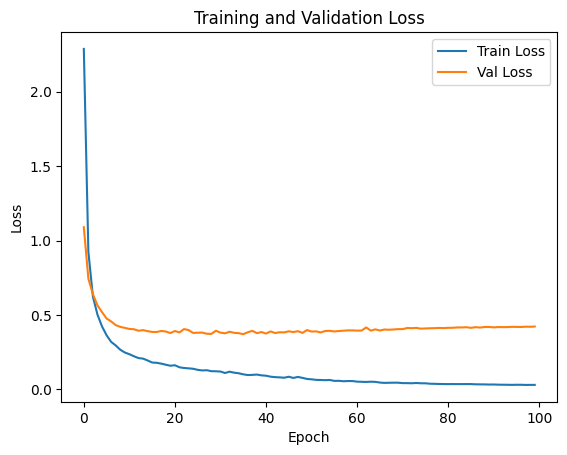

In [16]:
# pce
params = {
    'batch_size': 32,
    'lr':1e-3,
    'min_lr':1e-4,
    'epochs':100,
    'weight_decay':1e-4,
    'warmup_epochs':0,
    'device':device,
    'delta':0.15
}
# data division
dataset, dataloader = dataload((abs_train, PL_t, PL_b, label_train),(train_index, val_index, test_indices), params['batch_size'])

# model definition
spectrum_model = load_ptmodel('Pre-trained_model.pth',device)
model = model.FineTuneModel(spectrum_model, [18], 10, 36, dropout_rate=None).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr = params['lr'], weight_decay = params['weight_decay'])
# train
loss_list, val_loss_list, lr_list,best_model_path = fine_train(model, optimizer, dataloader[0], dataloader[1], params,'./models')

std: 2.6285009384155273, mean: 0.07280533760786057


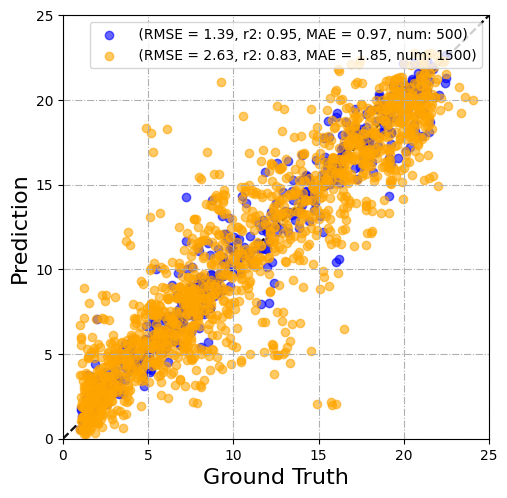

<Figure size 640x480 with 0 Axes>

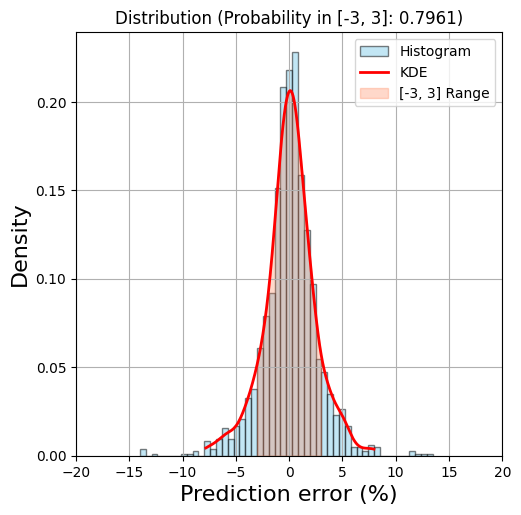

0.7961010693352566

In [18]:
# test

load_model = torch.load(best_model_path,weights_only=False,map_location='cpu')
load_model.eval()  

scale_cons = 25
# train
train_data = dataset[0].tensors[0]
y_train = (dataset[0].tensors[1].reshape(-1)*scale_cons).numpy()
y_train_pred,_ = load_model.forward(train_data.to('cpu'))
y_train_pred = y_train_pred.cpu().detach().numpy().reshape(-1)*scale_cons

# test
test_data = dataset[2].tensors[0]
y_test = (dataset[2].tensors[1].reshape(-1)*scale_cons).numpy()
y_test_pred,_ = load_model.forward(test_data.to('cpu'))
y_test_pred = y_test_pred.cpu().detach().numpy().reshape(-1)*scale_cons

fig,ax = plt.subplots(1,1,figsize=(5.5, 5.5))
myplots(ax,[y_train,y_test],[y_train_pred,y_test_pred],[0,scale_cons])

plt.figure(3)
print(f"std: {np.std(y_test_pred - y_test)}, mean: {np.mean(y_test_pred - y_test)}")
plot_distribution_and_calculate_probability(y_test_pred - y_test,[-3,3])